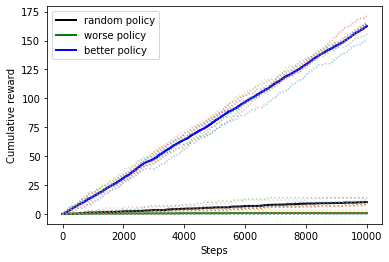

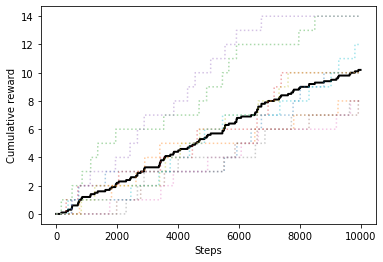

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Callable
from enum import IntEnum


class Action(IntEnum):
    """Action"""

    LEFT = 0
    DOWN = 1
    RIGHT = 2
    UP = 3


def actions_to_dxdy(action: Action):
    """
    Helper function to map action to changes in x and y coordinates

    Args:
        action (Action): taken action

    Returns:
        dxdy (Tuple[int, int]): Change in x and y coordinates
    """
    mapping = {
        Action.LEFT: (-1, 0),
        Action.DOWN: (0, -1),
        Action.RIGHT: (1, 0),
        Action.UP: (0, 1),
    }
    return mapping[action]


def reset():
    """Return agent to start state"""
    return (0, 0)

#Define a function to get all the stochastic options for an action
def perpen_a(action: Action):
    actions = []
    if action == 0 or action == 2:
        actions = [action, Action.UP, Action.DOWN]
    if action == 1 or action == 3:
        actions = [action, Action.LEFT, Action.RIGHT]
    return actions
    

# Q1
def simulate(state: Tuple[int, int], action: Action):
    """Simulate function for Four Rooms environment

    Implements the transition function p(next_state, reward | state, action).
    The general structure of this function is:
        1. If goal was reached, reset agent to start state
        2. Calculate the action taken from selected action (stochastic transition)
        3. Calculate the next state from the action taken (accounting for boundaries/walls)
        4. Calculate the reward

    Args:
        state (Tuple[int, int]): current agent position (e.g. (1, 3))
        action (Action): selected action from current agent position (must be of type Action defined above)

    Returns:
        next_state (Tuple[int, int]): next agent position
        reward (float): reward for taking action in state
    """
    # Walls are listed for you
    # Coordinate system is (x, y) where x is the horizontal and y is the vertical direction
    walls = [
        (0, 5),
        (2, 5),
        (3, 5),
        (4, 5),
        (5, 0),
        (5, 2),
        (5, 3),
        (5, 4),
        (5, 5),
        (5, 6),
        (5, 7),
        (5, 9),
        (5, 10),
        (6, 4),
        (7, 4),
        (9, 4),
        (10, 4),
    ]

    # TODO check if goal was reached
    goal_state = (10, 10)
    if state == goal_state:
        #print("goal reached need to reset")
        next_state = reset()
        reward = 1
        return next_state, reward

    # TODO modify action_taken so that 10% of the time, the action_taken is perpendicular to action (there are 2 perpendicular actions for each action)
    #The choice functions uses a probability distribution to sometimes select the actions perpendicular to the desired action, using the perpen_a function defined earlier
    action_taken = Action(np.random.choice(a=perpen_a(action), p=[0.9,0.05,0.05]))

    # TODO calculate the next state and reward given state and action_taken
    # You can use actions_to_dxdy() to calculate the next state
    # Check that the next state is within boundaries and is not a wall
    # One possible way to work with boundaries is to add a boundary wall around environment and
    # simply check whether the next state is a wall
    next_state = None
    next_state = tuple(map(lambda x,y: x + y, state, actions_to_dxdy(action_taken)))
    if next_state[0] > 10 or next_state[0] < 0:
        next_state = state
    if next_state[1] > 10 or next_state[1] < 0:
        next_state = state
    if next_state in walls:
        next_state = state
    
    reward = 0
        
    return next_state, reward


# Q2
def manual_policy(state: Tuple[int, int]):
    """A manual policy that queries user for action and returns that action

    Args:
        state (Tuple[int, int]): current agent position (e.g. (1, 3))

    Returns:
        action (Action)
    """
    manual_a = input(f"Current state, {state}\nEnter action(0:LEFT, 1:DOWN, 2:RIGHT, 3:UP): \n")
    manual_a = Action(int(manual_a))
    return manual_a

# Q2
def agent(
    steps: int = 1000,
    trials: int = 1,
    policy=Callable[[Tuple[int, int]], Action],
):
    """
    An agent that provides actions to the environment (actions are determined by policy), and receives
    next_state and reward from the environment

    The general structure of this function is:
        1. Loop over the number of trials
        2. Loop over total number of steps
        3. While t < steps
            - Get action from policy
            - Take a step in the environment using simulate()
            - Keep track of the reward
        4. Compute cumulative reward of trial

    Args:
        steps (int): steps
        trials (int): trials
        policy: a function that represents the current policy. Agent follows policy for interacting with environment.
            (e.g. policy=manual_policy, policy=random_policy)
    Returns:
        records (dict): cumulative rewards over steps organized by trial
    """
    records = {}
    
    # you can use the following structure and add to it as needed
    for t in range(trials):
        #print(f"trial {t}")
        state = reset()
        i = 0
        rewards = 0
        records[t] = []
        while i < steps:
            #print(f"step {i}")
            # select action to take
            action = policy(state)
            #print(f"action {action}")
            # take step in environment using simulate()
            state, reward = simulate(state, action)
            # record the reward
            rewards += reward
            records[t].append(rewards)
            i+=1
    return records

# Q3
def random_policy(state: Tuple[int, int]):
    """A random policy that returns an action uniformly at random

    Args:
        state (Tuple[int, int]): current agent position (e.g. (1, 3))

    Returns:
        action (Action)
    """
    # Using the random choice function to randomly take an action with equal probability
    return Action(np.random.choice(a=[Action.UP, Action.RIGHT, Action.LEFT, Action.DOWN], p=[0.25,0.25,0.25,0.25]))



# Q4
def worse_policy(state: Tuple[int, int]):
    """A policy that is worse than the random_policy

    Args:
        state (Tuple[int, int]): current agent position (e.g. (1, 3))

    Returns:
        action (Action)
    """
    return Action(np.random.choice(a=[Action.UP, Action.RIGHT], p=[0.5, 0.5]))


# Q4
def better_policy(state: Tuple[int, int]):
    """A policy that is better than the random_policy

    Args:
        state (Tuple[int, int]): current agent position (e.g. (1, 3))

    Returns:
        action (Action)
    """
    if state[1] <= 5:
        return Action(np.random.choice(a=[Action.UP, Action.RIGHT, Action.LEFT], p=[0.8, 0.1, 0.1]))
    else:
        if state[0] <=5:
            return Action(np.random.choice(a=[Action.UP, Action.RIGHT, Action.DOWN], p=[0.15, 0.8, 0.05])) 
        else:
            return Action(np.random.choice(a=[Action.UP, Action.RIGHT], p=[0.5, 0.5]))
        




In [ ]:
def main():
    # TODO run code for Q2~Q4 and plot results
    # You may be able to reuse the agent() function for each question
    
    #create 3 simulations with each of the 3 policies
    records_r = agent(steps=10000, trials=10, policy=random_policy)
    records_b = agent(steps=10000, trials=10, policy=better_policy)
    records_w = agent(steps=10000, trials=10, policy=worse_policy)

    #create lists where we can store the average value for the simulations by step
    avg_r = [0]*10000
    avg_b = [0]*10000
    avg_w = [0]*10000

    #for each trial in each simulation it adds its cumulative reward value indexed by step, then divides by trials
    for t in records_r:
        #print(f"trial {t}")
        avg_r = list(map(lambda x,y: x+y, avg_r, records_r[t]))
    avg_r = list(map(lambda x: x / len(records_r), avg_r))

    for t in records_b:
        #print(f"trial {t}")
        avg_b = list(map(lambda x,y: x+y, avg_b, records_b[t]))
    avg_b = list(map(lambda x: x / len(records_b), avg_b))

    for t in records_w:
        #print(f"trial {t}")
        avg_w = list(map(lambda x,y: x+y, avg_w, records_w[t]))
    avg_w = list(map(lambda x: x / len(records_w), avg_w))
        
    #I plot the trials each as dashed lines with 0.4 opacity, then plot the averages as slightly thicker opaque lines
    plt.plot(list(range(10000)), avg_r, 'k', linewidth=2)
    plt.plot(list(range(10000)), avg_w, 'g', linewidth=2)
    plt.plot(list(range(10000)), avg_b, 'b', linewidth=2)
    plt.legend(['random policy', 'worse policy', 'better policy'], loc='upper left')
    plt.xlabel('Steps')
    plt.ylabel('Cumulative reward')
    for t in records_r:
        plt.plot(list(range(10000)), records_r[t], ':', alpha=0.4)
        plt.plot(list(range(10000)), records_b[t], ':', alpha=0.4)
        plt.plot(list(range(10000)), records_w[t], ':', alpha=0.4)
    plt.savefig('exp_all_policies.pdf')
    plt.show()

    plt.plot(list(range(10000)), avg_r, 'k', linewidth=2)
    plt.xlabel('Steps')
    plt.ylabel('Cumulative reward')
    for t in records_r:
        plt.plot(list(range(10000)), records_r[t], ':', alpha=0.4)
    plt.savefig('exp_random.pdf')
    plt.show()
    
if __name__ == "__main__":
    main()
